In [1]:
import chipwhisperer as cw
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error 
from scipy import stats
import sys
import scipy.signal
sys.path.append("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/")
from privacy_amplification.FFT.FFT import *

SCOPETYPE = 'OPENADC'
PLATFORM = 'CW308_SAM4S'
SS_VER = 'SS_VER_2_1'

try:
    if not scope.connectStatus:
        scope.con()
except NameError:
    scope = cw.scope()

try:
    if SS_VER == "SS_VER_2_1":
        target_type = cw.targets.SimpleSerial2
    elif SS_VER == "SS_VER_2_0":
        raise OSError("SS_VER_2_0 is deprecated. Use SS_VER_2_1")
    else:
        target_type = cw.targets.SimpleSerial
except:
    SS_VER="SS_VER_1_1"
    target_type = cw.targets.SimpleSerial

try:
    target = cw.target(scope, target_type)
except:
    print("INFO: Caught exception on reconnecting to target - attempting to reconnect to scope first.")
    print("INFO: This is a work-around when USB has died without Python knowing. Ignore errors above this line.")
    scope = cw.scope()
    target = cw.target(scope, target_type)


print("INFO: Found ChipWhisperer😍")

if "STM" in PLATFORM or PLATFORM == "CWLITEARM" or PLATFORM == "CWNANO":
    prog = cw.programmers.STM32FProgrammer
elif PLATFORM == "CW303" or PLATFORM == "CWLITEXMEGA":
    prog = cw.programmers.XMEGAProgrammer
elif "neorv32" in PLATFORM.lower():
    prog = cw.programmers.NEORV32Programmer
elif PLATFORM == "CW308_SAM4S" or PLATFORM == "CWHUSKY":
    prog = cw.programmers.SAM4SProgrammer
else:
    prog = None

INFO: Found ChipWhisperer😍


In [2]:
import time
time.sleep(0.05)
scope.default_setup()

def reset_target(scope):
    if PLATFORM == "CW303" or PLATFORM == "CWLITEXMEGA":
        scope.io.pdic = 'low'
        time.sleep(0.1)
        scope.io.pdic = 'high_z' #XMEGA doesn't like pdic driven high
        time.sleep(0.1) #xmega needs more startup time
    elif "neorv32" in PLATFORM.lower():
        raise IOError("Default iCE40 neorv32 build does not have external reset - reprogram device to reset")
    elif PLATFORM == "CW308_SAM4S" or PLATFORM == "CWHUSKY":
        scope.io.nrst = 'low'
        time.sleep(0.25)
        scope.io.nrst = 'high_z'
        time.sleep(0.25)
    else:  
        scope.io.nrst = 'low'
        time.sleep(0.05)
        scope.io.nrst = 'high_z'
        time.sleep(0.05)

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 131124                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7370129.87012987         
scope.clock.adc_freq                     changed from 0                         to 29480519.48051948        
scope.clock.extclk_monitor_enabled       changed from True                      to False                    
scope.clock.extclk_tolerance             changed from 1144409.1796875           to 13096723.705530167       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2      

In [3]:
%run "/home/40265864@ecit.qub.ac.uk/chipwhisperer/jupyter/Setup_Scripts/Setup_Generic.ipynb"

INFO: Found ChipWhisperer😍
scope.clock.extclk_tolerance             changed from 13096723.705530167        to 149880108.32439613       


In [4]:
N=8
seg_count = int((N/2)*np.log2(N))

scope.adc.samples = 3000                 # Number of samples per segment
scope.adc.stream_mode = "segmented"            # Enable segmented capture
scope.adc.segments = seg_count          # Total number of segments to capture
#scope.adc.offset = 10

# Gain settings
#scope.gain.db = 30

# Trigger settings
#scope.trigger.triggers = "tio4"          # Make sure this matches your trigger pin
#scope.clock.clkgen_freq = 7370000        # Or whatever frequency your target uses
#scope.clock.adc_src = "clkgen_x4"

In [5]:
%%bash -s "$PLATFORM" "$SS_VER"
cd firmware/Toeplitz_FFT
make PLATFORM=$1 CRYPTO_TARGET=NONE SS_VER=$2 -j

SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
.
.
Welcome to another exciting ChipWhisperer target build!!
Compiling:
+--------------------------------------------------------
-en     Toeplitz_FFT.c ...
+ Built for platform Microchip SAM4S with:
arm-none-eabi-gcc (15:10.3-2021.07-4) 10.3.1 20210621 (release)
Copyright (C) 2020 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

+ CRYPTO_TARGET = NONE
+ CRYPTO_OPTIONS = AES128C
+--------------------------------------------------------
-e Done!
.
LINKING:
-en     Toeplitz_FFT-CW308_SAM4S.elf ...
-e Done!
.
.
.
.
Creating load file for Flash: Toeplitz_FFT-CW308_SAM4S.hex
Creating load file for Flash: Toeplitz_FFT-CW308_SAM4S.bin
arm-none-eabi-objcopy -O ihex -R .eeprom -R .fuse -R .lock -R .signature Toeplitz_FFT-CW308_SAM4S.elf Toeplitz_FFT-CW308_SAM4S.hex
Creating load file for EEPROM: Toeplitz_FFT-CW308

In [6]:
cw.program_target(scope, prog, "firmware/Toeplitz_FFT/Toeplitz_FFT-{}.hex".format(PLATFORM))

In [7]:
def align_traces(traces):
    ref_trace = traces[0]  # Use the first trace as reference
    aligned_traces = []

    for trace in traces:
        correlation = np.correlate(trace, ref_trace, mode="full")  # Compute cross-correlation
        shift = np.argmax(correlation) - (len(trace) - 1)  # Find best alignment
        aligned_trace = np.roll(trace, -shift)  # Shift the trace
        aligned_traces.append(aligned_trace)
    
    return np.array(aligned_traces)

In [8]:
def get_trace(x):
    #num_char = target.in_waiting()
    #while num_char > 0:
        #target.read(num_char, 10)
        #time.sleep(0.01)
        #num_char = target.in_waiting()
    time.sleep(0.1)
    #target.flush()
    scope.arm()
    target.write(x)
    if scope.capture():
        raise RuntimeError("Capture failed")
    trace_segments = scope.get_last_trace_segmented()
    alligned_traces = align_traces(trace_segments)
    return alligned_traces


In [16]:
traces = []
reset_target(scope)

##inital toeplitz setup
##target.write("00010\n")
#time.sleep(0.01)
##target.write("1010\n")


x1 = "00000000\n" # 00 on butterfly 1
x2 = "10000000\n" # 10 on butterfly 1
x3 = "00001000\n" # 01 on butterfly 1
x4 = "10001000\n" # 11 on butterfly 1



for i in range(4):
    warmup = get_trace(x2)

    

for i in range(10):
    traces.append(get_trace(x1))
for i in range(10):
    traces.append(get_trace(x2))
for i in range(10):
    traces.append(get_trace(x3))
for i in range(10):
    traces.append(get_trace(x4))
""""
for i in range(10):
    traces.append(get_trace(x3))
for i in range(10):
    traces.append(get_trace(x4))
for i in range(10):
    traces.append(get_trace(x5))
for i in range(10):
    traces.append(get_trace(x6))
"""

'"\nfor i in range(10):\n    traces.append(get_trace(x3))\nfor i in range(10):\n    traces.append(get_trace(x4))\nfor i in range(10):\n    traces.append(get_trace(x5))\nfor i in range(10):\n    traces.append(get_trace(x6))\n'

In [49]:
traces_x1 = []
traces_x2 = []
traces_x3 = []
traces_x4 = []
for i in range(10):
    traces_x1.append(traces[i])
    traces_x2.append(traces[i+10])
    traces_x3.append(traces[i+20])
    traces_x4.append(traces[i+30])
traces_x1_avg = np.mean(traces_x1, axis=0)
traces_x2_avg = np.mean(traces_x2, axis=0)
traces_x3_avg = np.mean(traces_x3, axis=0)
traces_x4_avg = np.mean(traces_x4, axis=0)

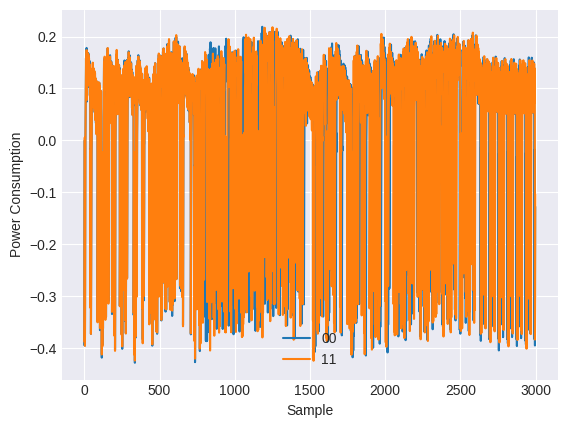

<Figure size 640x480 with 0 Axes>

In [50]:
plt.plot(traces_x1_avg[0], label="00")
plt.plot(traces_x4_avg[0], label="11")
plt.xlabel("Sample")
plt.ylabel("Power Consumption")
plt.legend()
plt.style.use('seaborn-v0_8-darkgrid')
plt.show()
plt.savefig("firmware/results/power_overlay.png",dpi=500)

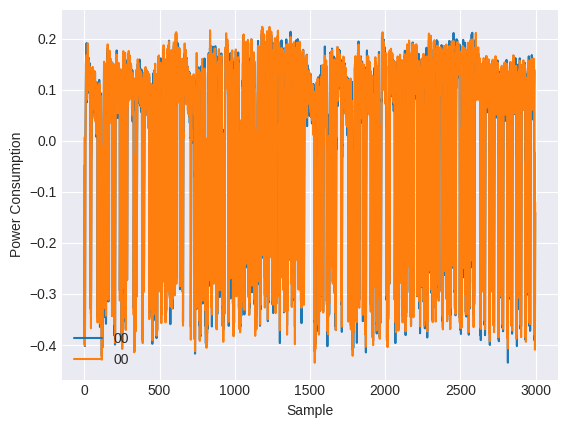

<Figure size 640x480 with 0 Axes>

In [56]:
plt.plot(traces[0][0], label="00")
plt.plot(traces[1][0], label="00")
plt.xlabel("Sample")
plt.ylabel("Power Consumption")
plt.legend()
plt.style.use('seaborn-v0_8-darkgrid')
plt.show()
plt.savefig("firmware/results/power_overlay_same.png",dpi=500)

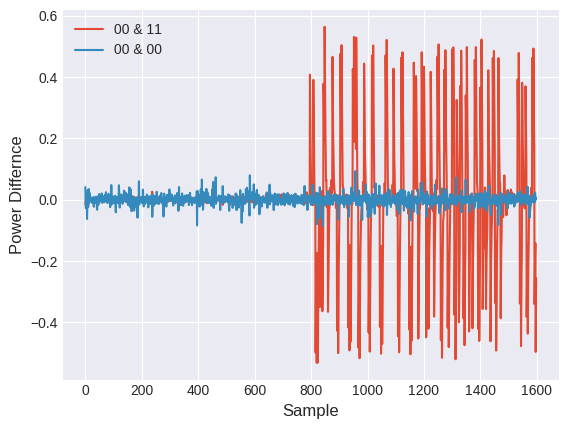

<Figure size 640x480 with 0 Axes>

In [81]:
plt.plot(traces_x1_avg[0] - traces_x4_avg[0], label= "00 & 11")
plt.plot(traces[0][0] - traces[1][0], label = "00 & 00")
plt.xlabel("Sample")
plt.ylabel("Power Differnce")
plt.style.use('seaborn-v0_8-darkgrid')
plt.legend()
plt.show()
plt.savefig("firmware/results/power_difference.png",dpi=500)

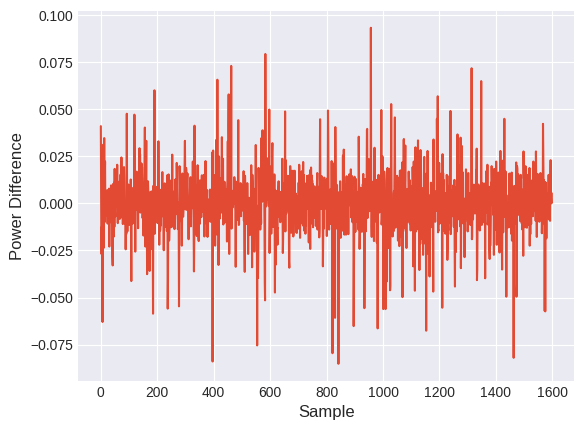

<Figure size 640x480 with 0 Axes>

In [78]:
plt.plot(traces[0][0] - traces[1][0])
plt.xlabel("Sample")
plt.ylabel("Power Difference")
plt.style.use('seaborn-v0_8-darkgrid')
plt.show()
plt.savefig("firmware/results/power_differnce_same.png",dpi=500)

In [54]:
cw.plot(traces_x1_avg[0]) * cw.plot(traces_x2_avg[0]) * cw.plot(traces_x3_avg[0]) * cw.plot(traces_x4_avg[0]) 


:Overlay
   .Curve.I   :Curve   [x]   (y)
   .Curve.II  :Curve   [x]   (y)
   .Curve.III :Curve   [x]   (y)
   .Curve.IV  :Curve   [x]   (y)

In [ ]:
cw.plot(traces_x2_avg[9] - traces_x1_avg[10])

In [ ]:
cw.plot(traces_x1_avg) * cw.plot(traces_x2_avg)

In [ ]:
def gen_hyp_string_basic(x):
    x_str = list("00000\n")
    x_bin = bin(x)[2:]
    x_bin = x_bin[::-1]
    for i in range(len(x_bin)):
        x_str[int(i)] = x_bin[i]
    x_str = ''.join(x_str)
    return x_str

1. Set a random key to be the correct key & record trace as reference trace
2. For the first 16 bits of the re-ordered key input, make a guess
3. Account for padded bits to reduce key space
4. For each guess, carry out FFT and record trace
5. Compare each guess to reference trace, select max correlation as guess

In [9]:
##let x be a decimal input for the bits 0,2,4,6,8,10,12,14,16,18
def gen_hyp_string_8_bit_chunk(x, offset):
    x_str = list("00000000000000000000\n")
    x_bin = bin(x)[2:]
    x_bin = x_bin[::-1]
    for i in range(len(x_bin)):
        x_str[int(4*i + offset)] = x_bin[i] ##change 1 to 4 in real scenario
    x_str = ''.join(x_str)
    return x_str

In [10]:
def make_guesses(offset):
    traces = []
    reset_target(scope)
    ##inital toeplitz setup
    target.write("01101\n")
    time.sleep(0.01)
    target.write("1010\n")
    x2 = "11111\n"
    for i in range(4):
        warmup = get_trace(x2)


    for i in range(32):
        if i % 200 == 0 and i != 0:
            target.flush()
            reset_target(scope)
            target.write("01101\n")
            time.sleep(0.01)
            target.write("1010\n")
            x2 = "11111\n"
            for i in range(4):
                warmup = get_trace(x2)

        x = gen_hyp_string_basic(i)
        print("Testing Hyptohesis {0}, input: {1}".format(i,x))
        traces.append(get_trace(x))

    return traces

In [ ]:
reset_target(scope)

##inital toeplitz setup
target.write("01101\n")
time.sleep(0.01)
target.write("1010\n")
x2 = "1111\n"
for i in range(4):
    warmup = get_trace(x2)

#x0 = "10001000000010000000\n"
#x0 = "11001101000010010100\n"
#x0 = "10110100100101100101\n" #x0 = "1011 0100 1001 0110 0101\n" ##x0=[10100] x1=[01011] x2=[10010] x3=[10101]
x0 = "01101\n"
time.sleep(0.1)
target_trace = get_trace(x0)


traces0 = make_guesses(0)
#traces2 = make_guesses(2)

In [ ]:
MSE = []
PC = []
for i in range(32):
    MSE.append(mean_squared_error(np.concatenate(target_trace), np.concatenate(traces0[i])))
    PC.append(stats.pearsonr(np.concatenate(target_trace), np.concatenate(traces0[i])))

    print("Guess {0}. MSE: {1}, PC: {2}".format(i,MSE[i], PC[i]))

In [ ]:
cw.plot(np.concatenate(target_trace) - np.concatenate(traces0[28])) * cw.plot(np.concatenate(target_trace) - np.concatenate(traces0[22]))

In [ ]:
print(np.argsort(np.asarray(MSE)))

In [9]:
def array_to_bin_input(arr):
    op = ""
    for x in arr:
        op = op + str(int(x))
    op = op + "\n"
    return op


In [10]:
def infer_from_traces(target_trace, template_traces, segment):
    ##built for 2 bit guesser

    MSE = []
    PC = []
    print("\n\nSegment {0}".format(segment))
    for i in range(4):
        MSE.append(mean_squared_error(target_trace[segment], template_traces[i][segment]))
        PC.append(stats.pearsonr(target_trace[segment],template_traces[i][segment]))
        print("Guess {0}. MSE: {1}, PC: {2}".format(i,MSE[i], PC[i]))
        
    best = np.argsort(MSE)[0]
    result = []
    match best:
        case 0:
            result = [0,0]
        case 1:
            result = [0,1]
        case 2:
            result = [1,0]
        case 3:
            result = [1,1]
    
    return result

In [11]:
def reverse_bits(n, bitSize):
    result = 0
    for i in range(bitSize):
        if n & (1 << i):
            result |= 1 << (bitSize - 1 - i)
    return result

def bit_reverse(x):
    N = x.shape[0]
    s = int(np.log2(N))
    for i in range(N):
        rb = reverse_bits(i,s)
        if(i < rb):
            tmp = x[i]
            x[i] = x[rb]
            x[rb] = tmp
    return x

def gen_pairs(N):
    pairs = []
    order_list = np.arange(N)
    reverse_order = bit_reverse(order_list)
    for i in range(int(N/2)):
        pairs.append([reverse_order[int(2*i)], reverse_order[int(2*i + 1)]])
    return pairs

In [12]:
def guess_sequentially_by_2(target_trace, repeats, N):
    ##modify to generate this on function input N (lenght of FFT)
    pairs = gen_pairs(N)
    key_hyp = np.zeros(N)
    segment = 0

    for pair in pairs:

        reset_target(scope)
        for _ in range(5):
            warmup_str = array_to_bin_input(np.ones(N))
            warmup = get_trace(warmup_str)

        traces_avg = []
        guesses = [[0,0], [0,1], [1,0], [1,1]]
        for guess in guesses:
            key_hyp[pair[0]] = guess[0]
            key_hyp[pair[1]] = guess[1]
            hyp_string = array_to_bin_input(key_hyp)
            traces = []
            for r in range(repeats):
                traces.append(get_trace(hyp_string))
            traces_avg.append(np.mean(traces,axis=0))
        
        result = infer_from_traces(target_trace, traces_avg, segment)
        key_hyp[pair[0]] = result[0]
        key_hyp[pair[1]] = result[1]
        segment += 1
    return key_hyp




In [13]:
import csv
def write_trace(file, input, noise, segments,  seg_len, trace):
    with open(file, 'a',newline='') as csvfile:
        writer = csv.writer(csvfile,delimiter=',')
        flattened = trace.flatten().tolist()

        writer.writerow([input,noise,segments,seg_len,flattened])


In [14]:
def run_attack(repeats, sigma):
    reset_target(scope)
    correct_key = np.random.randint(2,size=N)
    correct_key_str = array_to_bin_input(correct_key)
    print(correct_key)

    for _ in range(5):
        warmup_str = array_to_bin_input(np.ones(N))
        warmup = get_trace(warmup_str)

    target_trace = get_trace(correct_key_str)
    trace_pre = target_trace.copy()
    ##add noise to target trace
    for seg in range(seg_count):
            target_trace[seg] = target_trace[seg] + np.random.normal(0,sigma,scope.adc.samples-1)


    start = time.time()
    guess = guess_sequentially_by_2(target_trace, 1, N)
    end = time.time()

    time_taken = end - start

    guess = np.asarray(guess,dtype=int)
    correct_key = np.asarray(correct_key,dtype=int)
    print("\n{0} : Eve's Guess".format(guess))
    print("{0} : Correct Key".format(correct_key))
    cor_count = 0
    for i in range(N):
        if guess[i] == correct_key[i]:
            cor_count = cor_count+1
        
    if(guess == correct_key).all():
        print("Successfull Key Recovery")
    else:
        print("Incorrect Key Recovery, {0}% Correct".format(cor_count/N *100))
    print("Time Taken: {0}s".format(time_taken))

    return cor_count

[1 0 1 0 0 0 0 0]


Segment 0
Guess 0. MSE: 0.021101550365853764, PC: PearsonRResult(statistic=0.6213820873675859, pvalue=6.571e-320)
Guess 1. MSE: 0.034899859437945685, PC: PearsonRResult(statistic=0.37544191761034185, pvalue=5.125660364962296e-101)
Guess 2. MSE: 0.0002609973909378688, PC: PearsonRResult(statistic=0.995317541278077, pvalue=0.0)
Guess 3. MSE: 0.03609802652176478, PC: PearsonRResult(statistic=0.35416314737356885, pvalue=2.4625377097225053e-89)


Segment 1
Guess 0. MSE: 0.021281517040892498, PC: PearsonRResult(statistic=0.618571085494628, pvalue=3.19303797e-316)
Guess 1. MSE: 0.016098979136354725, PC: PearsonRResult(statistic=0.7111578275779575, pvalue=0.0)
Guess 2. MSE: 0.0002624059407144199, PC: PearsonRResult(statistic=0.9953031339048395, pvalue=0.0)
Guess 3. MSE: 0.03157879460370711, PC: PearsonRResult(statistic=0.433868854140465, pvalue=6.326441871274738e-138)


Segment 2
Guess 0. MSE: 0.00026673358772229494, PC: PearsonRResult(statistic=0.9952126867399285, pvalue=0

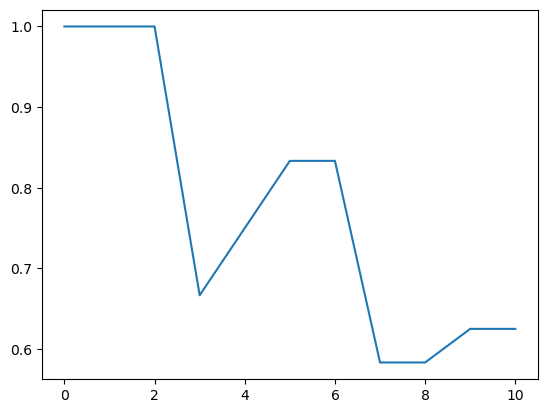

In [15]:
sigma = [0,1,2,3,4,5,6,7,8,9,10]
repeats = 3
rec_rate = []
for sig in sigma:
    results = []
    for r in range(repeats):
        results.append(run_attack(1,sig))
    rec_rate.append(np.asarray(results).mean(axis=0)/N)

plt.plot(sigma,rec_rate)

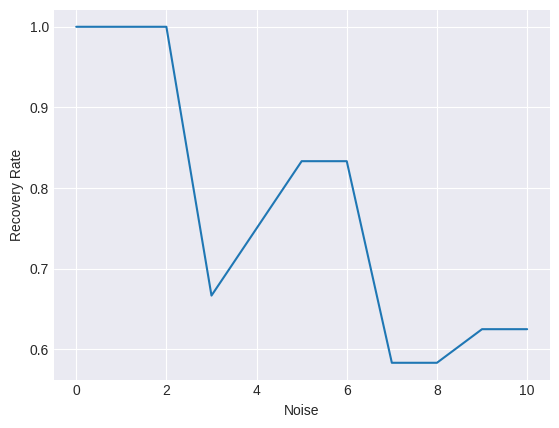

In [17]:
plt.plot(sigma,rec_rate)
plt.xlabel("Noise")
plt.ylabel("Recovery Rate")
plt.style.use('seaborn-v0_8-darkgrid')
plt.show()

In [48]:
cw.plot(target_trace[0] - trace_pre[0])

:Curve   [x]   (y)

In [42]:
cw.plot(target_trace[0]) * cw.plot(target_trace[1])

:Overlay
   .Curve.I  :Curve   [x]   (y)
   .Curve.II :Curve   [x]   (y)